In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
df = pd.read_csv(r"C:\Users\yogit\OneDrive\Desktop\Data_set\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.shape

(7043, 21)

In [5]:

df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df.dtypes


customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [8]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')



In [9]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
7038    False
7039    False
7040    False
7041    False
7042    False
Length: 7043, dtype: bool

In [10]:
df.duplicated().sum()


0

In [11]:
df[df['TotalCharges'].isna()][['tenure', 'TotalCharges']]


,tenure,TotalCharges
488,0,NaN
753,0,NaN
936,0,NaN
1082,0,NaN
1340,0,NaN
3331,0,NaN
3826,0,NaN
4380,0,NaN
5218,0,NaN
6670,0,NaN


In [12]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [13]:
df['TotalCharges'].isnull().sum()


11

In [14]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [15]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df[['tenure', 'TotalCharges']].loc[df['tenure'] == 0].head()


,tenure,TotalCharges
488,0,1397.475
753,0,1397.475
936,0,1397.475
1082,0,1397.475
1340,0,1397.475


In [16]:
df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe()


,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2281.916928
std,24.559481,30.090047,2265.270398
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,402.225000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


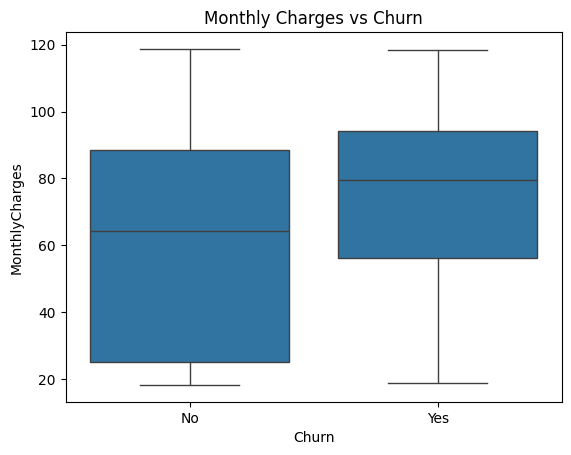

In [17]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()


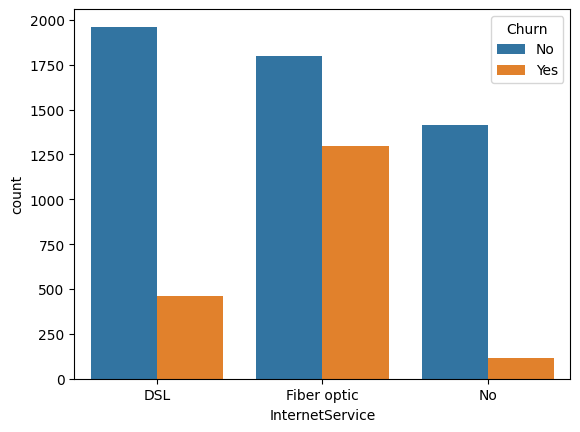

In [18]:
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.show()


In [19]:
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

df_encoded = pd.get_dummies(df.drop('Churn', axis=1), drop_first=True)
df_encoded['Churn'] = df['Churn']


In [20]:
corr = df_encoded.corr()['Churn'].sort_values(ascending=False)


In [21]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [22]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=2000,
    solver='lbfgs',
    class_weight='balanced'
)

log_model.fit(X_train_scaled, y_train)


LogisticRegression(class_weight='balanced', max_iter=2000)

In [24]:
from sklearn.metrics import roc_auc_score

y_pred_log = log_model.predict(X_test_scaled)
y_proba_log = log_model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_log))

              precision    recall  f1-score   support

           0       0.82      0.92      0.87      1035
           1       0.67      0.43      0.53       374

    accuracy                           0.79      1409
   macro avg       0.75      0.68      0.70      1409
weighted avg       0.78      0.79      0.78      1409

ROC-AUC: 0.830047275827327


In [25]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=20,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_split=20, n_estimators=300, random_state=42)

In [26]:
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))



              precision    recall  f1-score   support

           0       0.91      0.68      0.77      1035
           1       0.47      0.81      0.60       374

    accuracy                           0.71      1409
   macro avg       0.69      0.74      0.69      1409
weighted avg       0.79      0.71      0.73      1409

ROC-AUC: 0.8210157844428945


In [27]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(10)

tenure                                0.070683
Contract_Two year                     0.065018
PaymentMethod_Electronic check        0.060349
InternetService_Fiber optic           0.057785
MonthlyCharges                        0.048570
TotalCharges                          0.048327
OnlineBackup_No internet service      0.048165
TechSupport_No internet service       0.047381
InternetService_No                    0.040079
OnlineSecurity_No internet service    0.035758
dtype: float64

In [28]:
threshold = 0.35
y_pred_custom = (y_proba_rf >= threshold).astype(int)

print(confusion_matrix(y_test, y_pred_custom))
print(classification_report(y_test, y_pred_custom))
print(accuracy_score(y_test, y_pred_custom))

[[292 743]
 [ 16 358]]
              precision    recall  f1-score   support

           0       0.95      0.28      0.43      1035
           1       0.33      0.96      0.49       374

    accuracy                           0.46      1409
   macro avg       0.64      0.62      0.46      1409
weighted avg       0.78      0.46      0.45      1409

0.46132008516678497


In [29]:
pip install fastapi uvicorn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.1.2 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:
import pickle
import os

model = rf_model # your trained Random Forest

os.makedirs("model", exist_ok=True)

# Save model
pickle.dump(model, open("model/churn_model.pkl", "wb"))

# Save scaler (only if you used scaling)
pickle.dump(scaler, open("model/scaler.pkl", "wb"))

# Save feature order
pickle.dump(list(X.columns), open("model/feature_order.pkl", "wb"))


In [32]:
import pickle
pickle.load(open("model/churn_model.pkl", "rb"))


RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_split=20, n_estimators=300, random_state=42)

In [33]:
pickle.load(open("model/feature_order.pkl", "rb"))


['SeniorCitizen',
 'tenure',
 'MonthlyCharges',
 'TotalCharges',
 'customerID_0003-MKNFE',
 'customerID_0004-TLHLJ',
 'customerID_0011-IGKFF',
 'customerID_0013-EXCHZ',
 'customerID_0013-MHZWF',
 'customerID_0013-SMEOE',
 'customerID_0014-BMAQU',
 'customerID_0015-UOCOJ',
 'customerID_0016-QLJIS',
 'customerID_0017-DINOC',
 'customerID_0017-IUDMW',
 'customerID_0018-NYROU',
 'customerID_0019-EFAEP',
 'customerID_0019-GFNTW',
 'customerID_0020-INWCK',
 'customerID_0020-JDNXP',
 'customerID_0021-IKXGC',
 'customerID_0022-TCJCI',
 'customerID_0023-HGHWL',
 'customerID_0023-UYUPN',
 'customerID_0023-XUOPT',
 'customerID_0027-KWYKW',
 'customerID_0030-FNXPP',
 'customerID_0031-PVLZI',
 'customerID_0032-PGELS',
 'customerID_0036-IHMOT',
 'customerID_0040-HALCW',
 'customerID_0042-JVWOJ',
 'customerID_0042-RLHYP',
 'customerID_0048-LUMLS',
 'customerID_0048-PIHNL',
 'customerID_0052-DCKON',
 'customerID_0052-YNYOT',
 'customerID_0056-EPFBG',
 'customerID_0057-QBUQH',
 'customerID_0058-EVZWM',

In [31]:
from fastapi import FastAPI
import pickle
import numpy as np

app = FastAPI(title="Customer Churn Prediction API")

# Load artifacts
model = pickle.load(open("model/churn_model.pkl", "rb"))
scaler = pickle.load(open("model/scaler.pkl", "rb"))
FEATURE_ORDER = pickle.load(open("model/feature_order.pkl", "rb"))

@app.post("/predict")
def predict(data: dict):
    try:
        # Ensure correct feature order
        input_data = [data[feature] for feature in FEATURE_ORDER]
    except KeyError as e:
        return {"error": f"Missing feature: {str(e)}"}

    input_array = np.array(input_data).reshape(1, -1)

    # Scale input
    input_scaled = scaler.transform(input_array)

    prediction = model.predict(input_scaled)[0]
    probability = model.predict_proba(input_scaled)[0][1]

    return {
        "churn_prediction": int(prediction),
        "churn_probability": round(float(probability), 3)
    }
